# Incident Trend Analysis Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset
df = pd.read_csv("incident_trend_analysis_dataset.csv")

In [3]:
# Convert date column to atetimde format
df["Date Reported"] = pd.to_datetime(df["Date Reported"])
df["Month"] = df["Date Reported"].dt.to_period("M")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Incident ID             500 non-null    object        
 1   Date Reported           500 non-null    datetime64[ns]
 2   Incident Type           500 non-null    object        
 3   Priority                500 non-null    object        
 4   Department              500 non-null    object        
 5   Status                  500 non-null    object        
 6   Resolution Time (days)  500 non-null    int64         
 7   Month                   500 non-null    period[M]     
dtypes: datetime64[ns](1), int64(1), object(5), period[M](1)
memory usage: 31.4+ KB


# Exploratory Data Analysis (EDA)

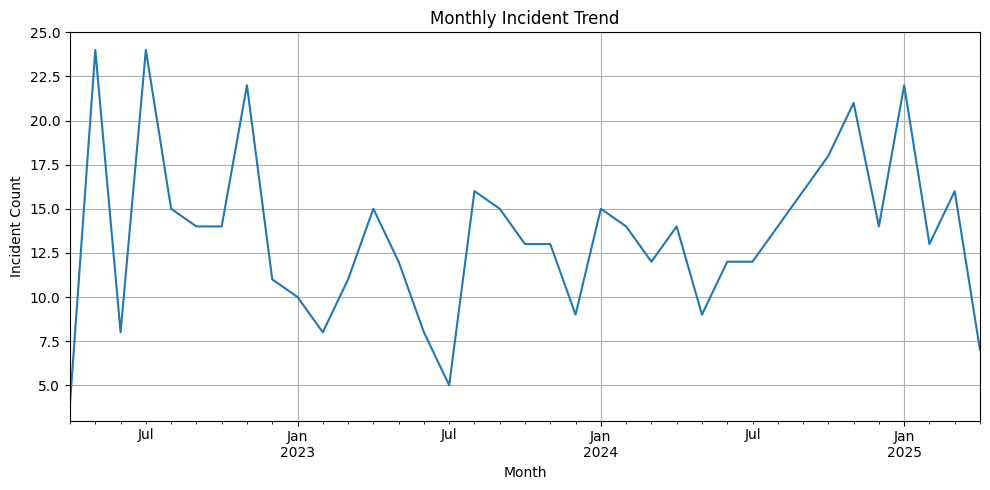

In [5]:
# Monthly incident trend
incident_trend = df.groupby("Month").size()
incident_trend.plot(kind="line", title="Monthly Incident Trend", ylabel="Incident Count", figsize=(10, 5))
plt.grid(True)
plt.tight_layout()
plt.show()

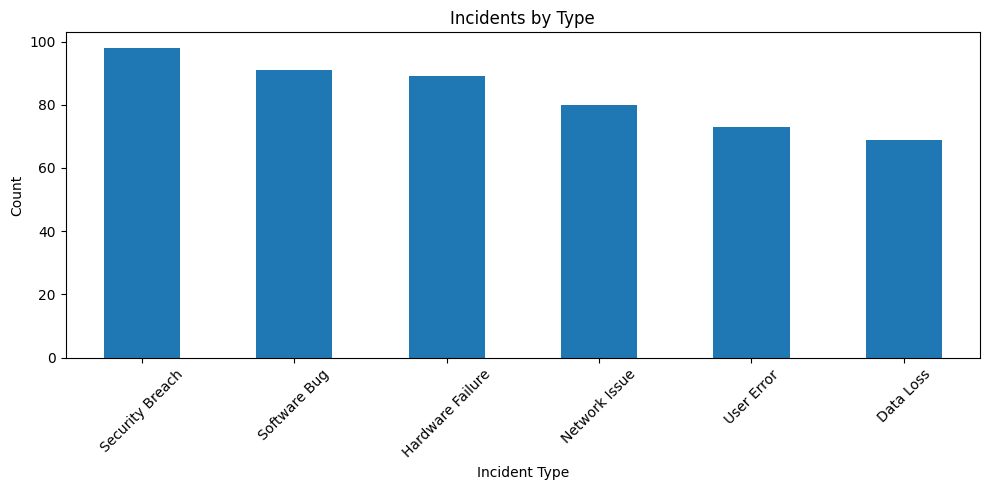

In [6]:
# Incidents by Type
df["Incident Type"].value_counts().plot(kind="bar", title="Incidents by Type", figsize=(10, 5))
plt.xlabel("Incident Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

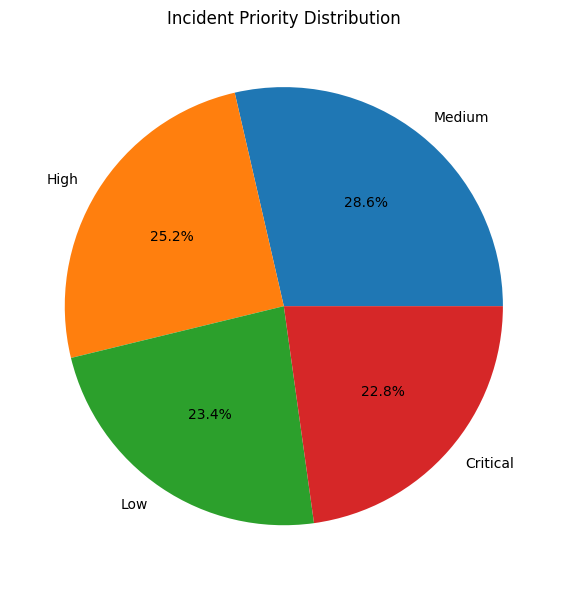

In [7]:
# Priority Distribution
df["Priority"].value_counts().plot(kind="pie", autopct='%1.1f%%', title="Incident Priority Distribution", figsize=(6, 6))
plt.ylabel("")
plt.tight_layout()
plt.show()

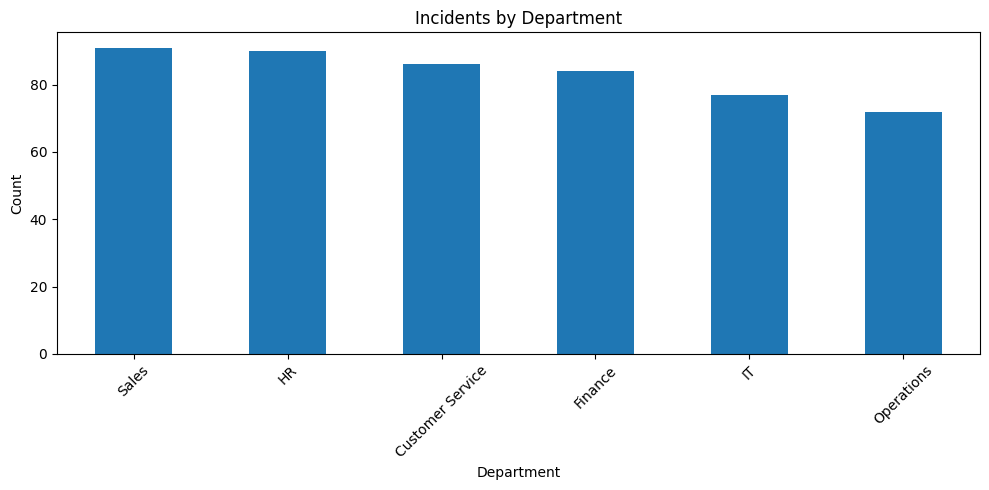

In [8]:
# Department Involvement
df["Department"].value_counts().plot(kind="bar", title="Incidents by Department", figsize=(10, 5))
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


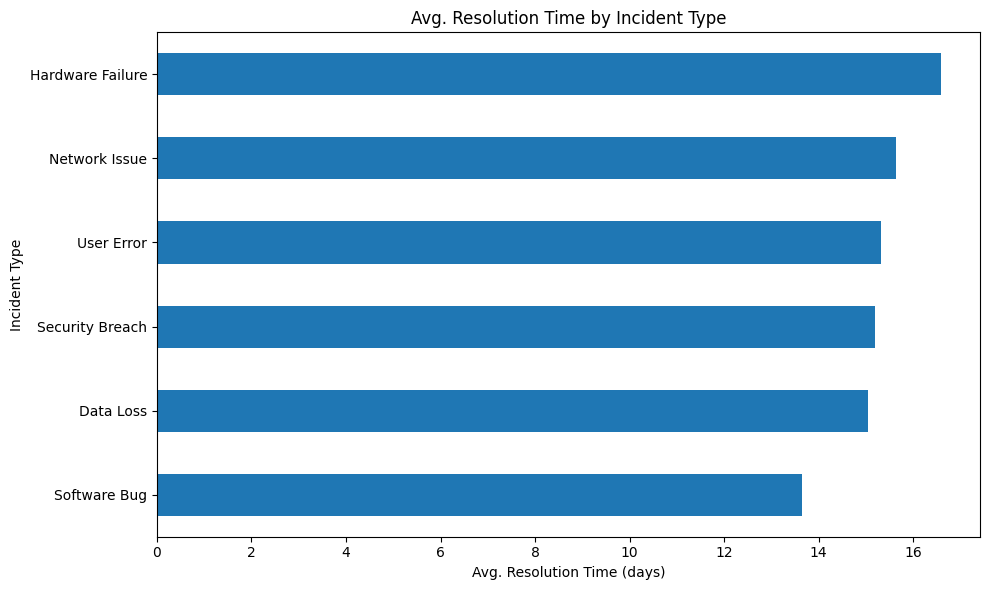

In [9]:
# Average Resolution Time by Incident Type
df.groupby("Incident Type")["Resolution Time (days)"].mean().sort_values().plot(kind="barh", title="Avg. Resolution Time by Incident Type", figsize=(10, 6))
plt.xlabel("Avg. Resolution Time (days)")
plt.tight_layout()
plt.show()

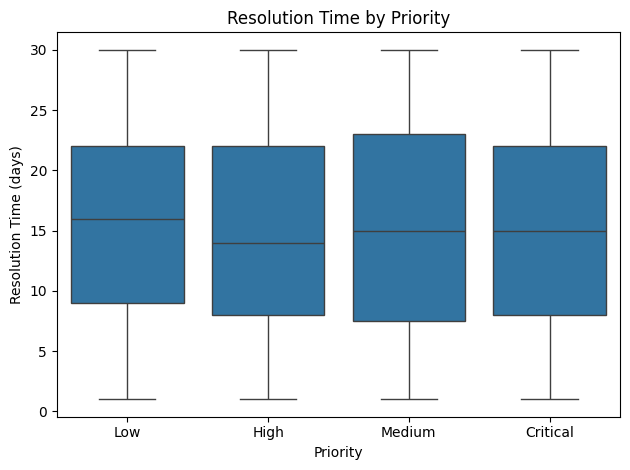

In [10]:
# Priority vs Resolution Time
sns.boxplot(x="Priority", y="Resolution Time (days)", data=df)
plt.title("Resolution Time by Priority")
plt.tight_layout()
plt.show()

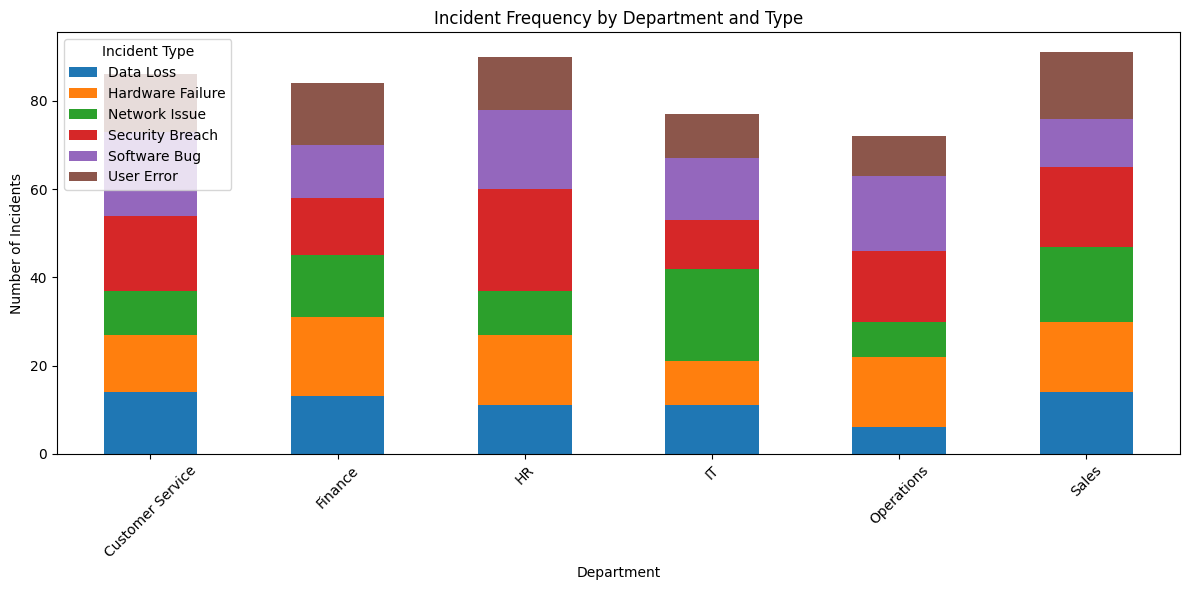

In [11]:
# Incident Frequency Heatmap by Department and Type
ct = pd.crosstab(df["Department"], df["Incident Type"])
ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Incident Frequency by Department and Type")
plt.xlabel("Department")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Save clean dataset (optional)
df.to_csv("clean_incident_data.csv", index=False)